In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROJECT_ROOT = Path.cwd().parent
SURFACES_DIR = PROJECT_ROOT / 'data' / 'surfaces'
FIG_DIR = PROJECT_ROOT / 'results' / 'svi' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TAB_DIR = PROJECT_ROOT / 'results' / 'svi' / 'tables'
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Load outputs from fit_surfaces.py
params = pd.read_parquet(SURFACES_DIR / 'ssvi_params.parquet')
diag = pd.read_parquet(SURFACES_DIR / 'ssvi_diagnostics.parquet')

# Load cleaned data for overlay plots
CLEAN = PROJECT_ROOT / 'data' / 'cleaned'
cme = pd.read_parquet(CLEAN / 'cme_options_clean.parquet')
der = pd.read_parquet(CLEAN / 'deribit_options_clean.parquet')
# Trim Deribit to CME window
der = der[(der['date'] >= '2020-01-13') & (der['date'] <= '2023-08-31')]

print(f"Fitted parameters: {len(params):,} slices")
print(f"Diagnostics: {len(diag):,} day-venue pairs")
print(f"Venues: {diag['venue'].value_counts().to_dict()}")

Fitted parameters: 8,912 slices
Diagnostics: 2,099 day-venue pairs
Venues: {'DER': 1327, 'CME': 772}


#### 1. RMSE Distribution per Venue (Thesis Table)

In [2]:
rmse_table = diag.groupby('venue')['rmse'].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).round(4)
rmse_table['mean_pct'] = (rmse_table['mean'] * 100).round(2)
rmse_table['median_pct'] = (rmse_table['50%'] * 100).round(2)
print("SSVI Calibration RMSE Summary:")
print(rmse_table)

# Save for LaTeX
rmse_table.to_csv(TAB_DIR / 'ssvi_rmse_summary.csv')

SSVI Calibration RMSE Summary:
        count    mean     std     min      5%     25%     50%     75%     95%  \
venue                                                                           
CME     772.0  0.0168  0.0077  0.0007  0.0055  0.0112  0.0163  0.0220  0.0303   
DER    1327.0  0.0258  0.0086  0.0092  0.0155  0.0203  0.0243  0.0293  0.0418   

          max  mean_pct  median_pct  
venue                                
CME    0.0593      1.68        1.63  
DER    0.0798      2.58        2.43  


C:\Users\Lucal\AppData\Local\Temp\ipykernel_27148\1706358996.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['CME', 'Deribit'], showfliers=True,


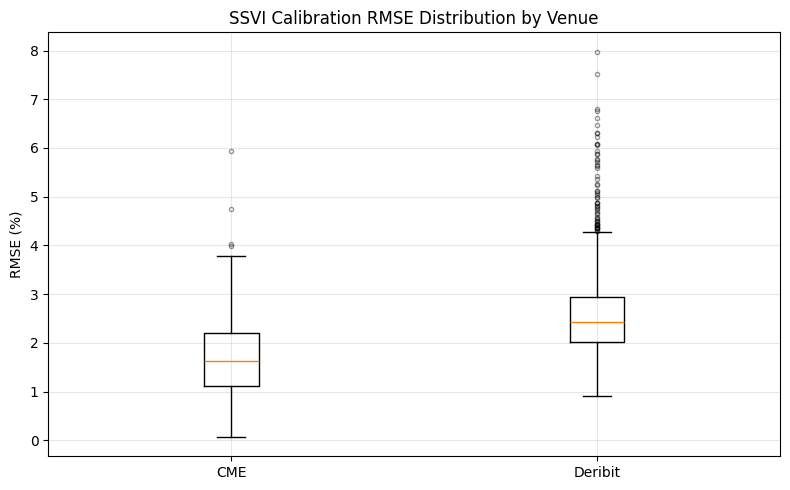

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
data_box = [diag[diag['venue']==v]['rmse'].dropna().values * 100 for v in ['CME', 'DER']]
bp = ax.boxplot(data_box, labels=['CME', 'Deribit'], showfliers=True,
                flierprops={'marker': 'o', 'alpha': 0.4, 'markersize': 3})
ax.set_ylabel('RMSE (%)')
ax.set_title('SSVI Calibration RMSE Distribution by Venue')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_ssvi_rmse_boxplot.png', dpi=150)
plt.show()

#### 2. RMSE Time Series

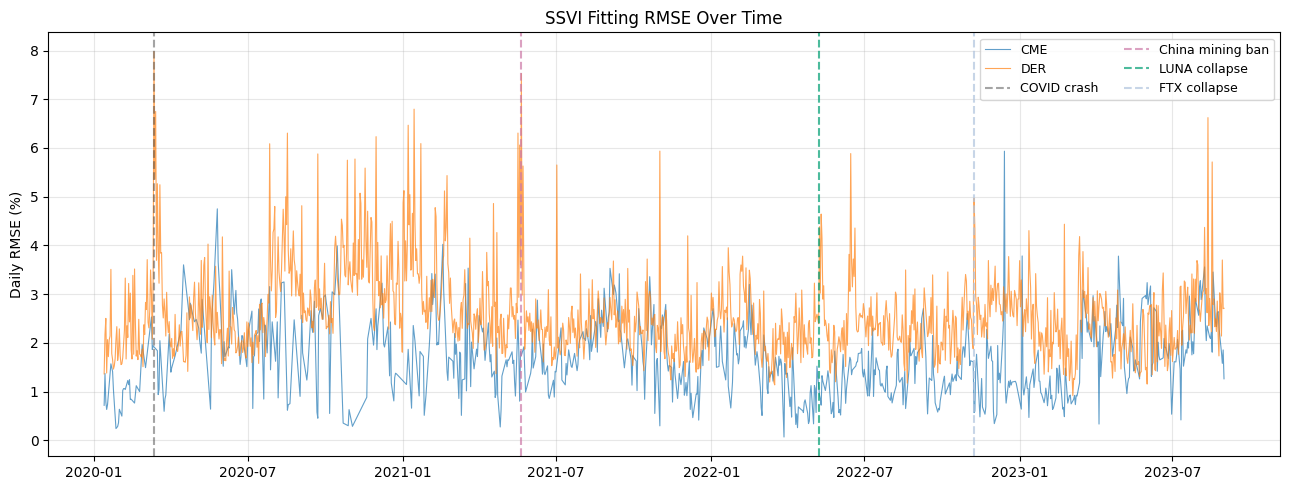


CME — 5 worst-fit days:
      date     rmse  n_slices  n_options
2022-12-14 0.059342         3         30
2020-05-26 0.047507         2         39
2021-02-17 0.040222         3         60
2020-10-15 0.039895         3        135
2023-01-04 0.037835         3         31

DER — 5 worst-fit days:
      date     rmse  n_slices  n_options
2020-03-12 0.079792         3         41
2021-05-21 0.075278         5        103
2021-01-14 0.067974         5        127
2020-03-14 0.067507         3         44
2023-08-12 0.066236         5        126


In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
for venue, color in [('CME', 'C0'), ('DER', 'C1')]:
    v = diag[diag['venue'] == venue].set_index('date')['rmse'] * 100
    ax.plot(v.index, v.values, label=venue, alpha=0.7, color=color, linewidth=0.8)

events = [ 
    ("2020-03-12", "--", "COVID crash", "#4A4A4A", 0.5),
    ("2021-05-21", "--", "China mining ban", "#CC79A7", 0.7),
    ("2022-05-09", "--", "LUNA collapse", "#009E73", 0.7),
    ("2022-11-08", "--", "FTX collapse", "#B0C4DE", 0.7),
]

for date, style, label, color, alpha in events:
    ax.axvline(pd.Timestamp(date), color=color, linestyle=style, alpha=alpha, label=label)

ax.set_ylabel('Daily RMSE (%)')
ax.set_title('SSVI Fitting RMSE Over Time')
ax.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_ssvi_rmse_timeseries.png', dpi=150)
plt.show()

# Identify worst days per venue
for venue in ['CME', 'DER']:
    v = diag[diag['venue'] == venue].nlargest(5, 'rmse')
    print(f"\n{venue} — 5 worst-fit days:")
    print(v[['date', 'rmse', 'n_slices', 'n_options']].to_string(index=False))

#### 3. Fitted Parameter Evolution

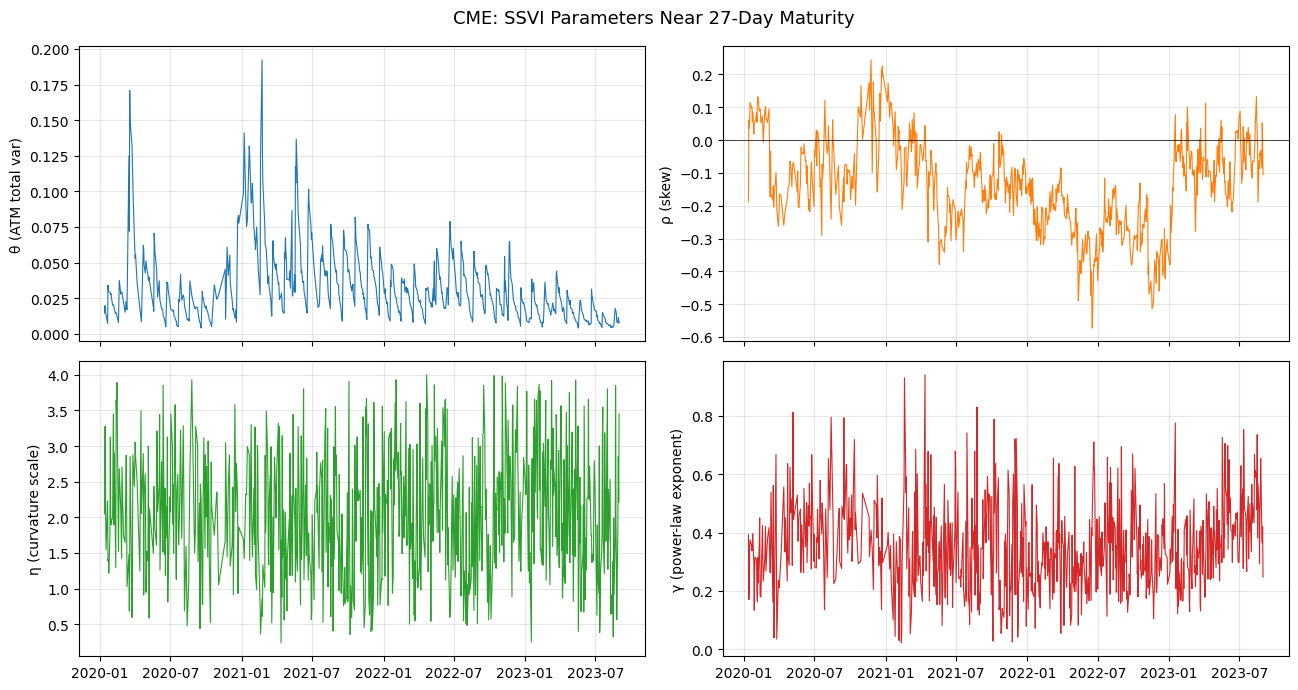

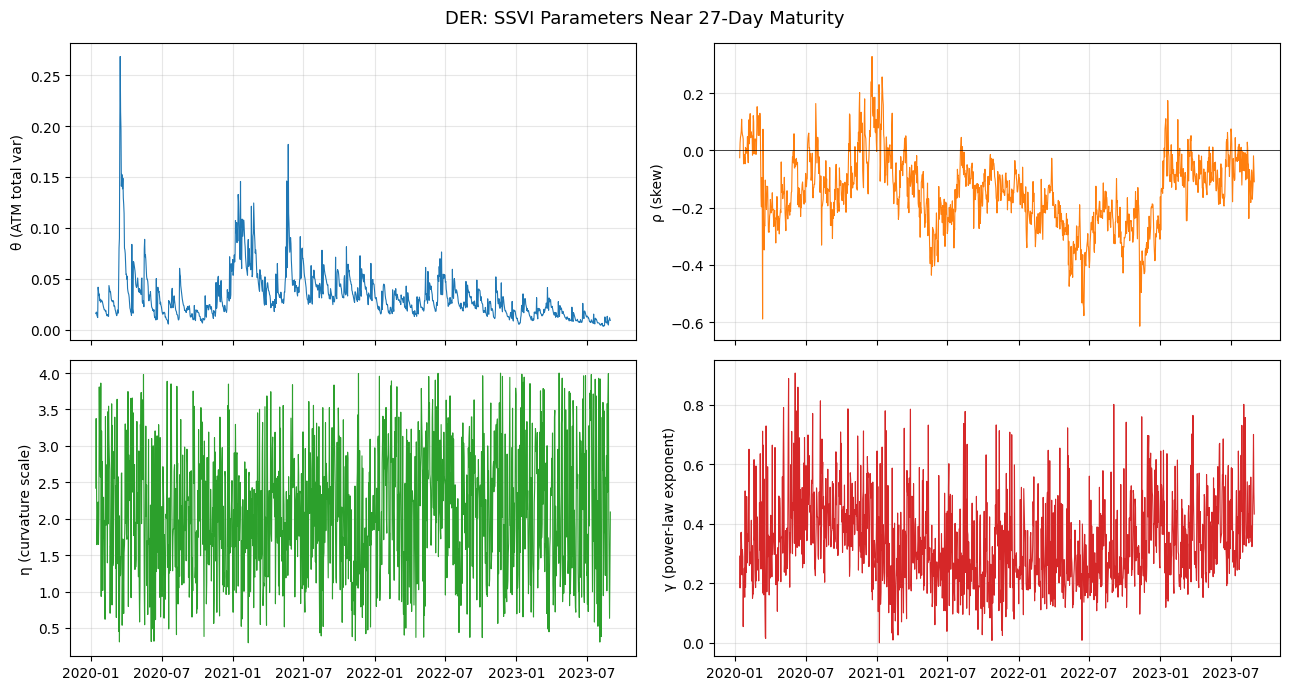

In [5]:
for venue in ['CME', 'DER']:
    p_v = params[params['venue'] == venue].copy()
    # Select the maturity closest to 27 days per date
    p_v['dist_27'] = (p_v['days_to_expiry'] - 27).abs()
    p_27 = p_v.loc[p_v.groupby('date')['dist_27'].idxmin()]
    p_27 = p_27.set_index('date').sort_index()
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
    fig.suptitle(f'{venue}: SSVI Parameters Near 27-Day Maturity', fontsize=13)
    
    axes[0,0].plot(p_27.index, p_27['theta'], linewidth=0.8)
    axes[0,0].set_ylabel('θ (ATM total var)')
    
    axes[0,1].plot(p_27.index, p_27['rho'], linewidth=0.8, color='C1')
    axes[0,1].set_ylabel('ρ (skew)')
    axes[0,1].axhline(0, color='black', linewidth=0.5)
    
    axes[1,0].plot(p_27.index, p_27['eta'], linewidth=0.8, color='C2')
    axes[1,0].set_ylabel('η (curvature scale)')
    
    axes[1,1].plot(p_27.index, p_27['gamma'], linewidth=0.8, color='C3')
    axes[1,1].set_ylabel('γ (power-law exponent)')
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'fig_ssvi_params_{venue.lower()}.png', dpi=150)
    plt.show()

#### 4. Sample Fitted Surfaces

Visualize fitted IV surfaces on a calm day and a stress day for each venue.

In [6]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[0] 

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.surfaces.ssvi import SSVI

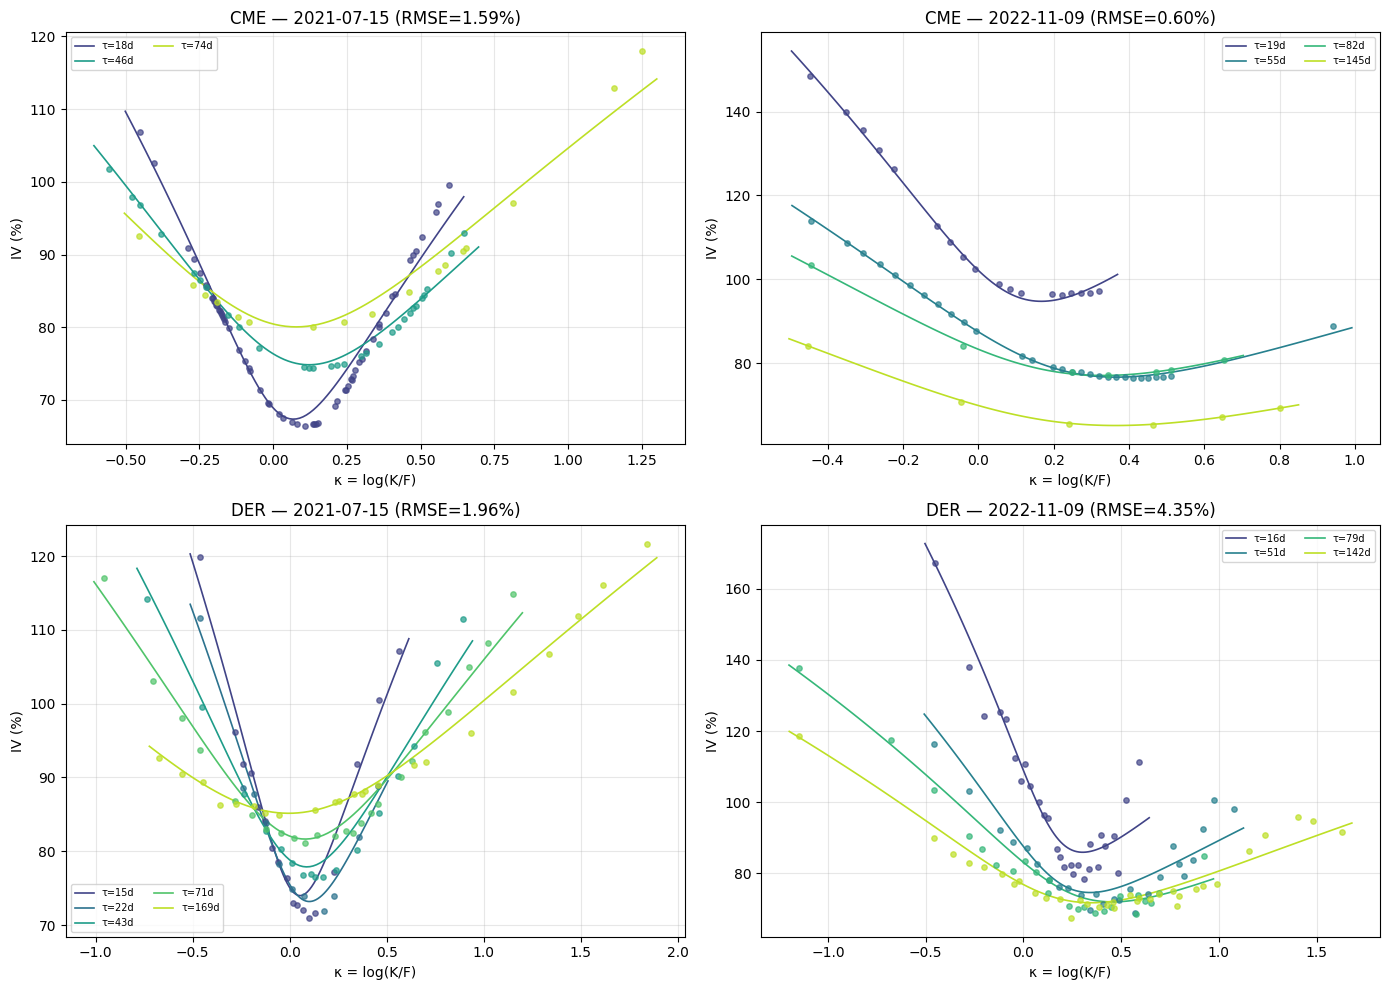

In [7]:
def plot_fitted_surface(df_venue, venue, target_date, ax):
    """Fits and plots the SSVI surface for a single (venue, date)."""
    target_date = pd.Timestamp(target_date)
    df_day = df_venue[df_venue['date'] == target_date]
    if df_day.empty:
        ax.set_title(f'{venue} — {target_date.date()} (no data)')
        return
    
    try:
        ssvi = SSVI(df_day, venue=venue, date=target_date)
        ssvi.fit()
        metrics = ssvi.evaluate_fit()
    except Exception as e:
        ax.set_title(f'{venue} — {target_date.date()} (fit failed: {e})')
        return
    
    # Plot observed vs fitted per maturity slice
    Ts = ssvi.res['maturities']
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(Ts)))
    
    for j, T in enumerate(Ts):
        mask = df_day['tau'] == T
        k_obs = df_day.loc[mask, 'log_moneyness'].values
        iv_obs = df_day.loc[mask, 'impliedvolatility'].values * 100
        ax.scatter(k_obs, iv_obs, color=colors[j], s=15, alpha=0.7, zorder=3)
        
        # Fitted curve
        k_grid = np.linspace(k_obs.min() - 0.05, k_obs.max() + 0.05, 100)
        theta = ssvi.res['theta'][T]
        phi = ssvi._phi_power_law(theta, ssvi.res['eta'][T], ssvi.res['gamma'][T])
        w_fit = ssvi._ssvi_total_variance(k_grid, theta, ssvi.res['rho'][T], phi)
        iv_fit = np.sqrt(np.maximum(w_fit, 0) / T) * 100
        dte = round(T * 365.25)
        ax.plot(k_grid, iv_fit, color=colors[j], linewidth=1.2,
                label=f'τ={dte}d')
    
    ax.set_xlabel('κ = log(K/F)')
    ax.set_ylabel('IV (%)')
    ax.set_title(f"{venue} — {target_date.date()} (RMSE={metrics['rmse']*100:.2f}%)")
    ax.legend(fontsize=7, ncol=2)

# Pick representative dates: one calm, one stressed
calm_date = '2021-07-15'   # Mid-2021, relatively calm
stress_date = '2022-11-09' # Day after FTX collapse

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_fitted_surface(cme, 'CME', calm_date, axes[0, 0])
plot_fitted_surface(cme, 'CME', stress_date, axes[0, 1])
plot_fitted_surface(der, 'DER', calm_date, axes[1, 0])
plot_fitted_surface(der, 'DER', stress_date, axes[1, 1])
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_ssvi_sample_surfaces.png', dpi=150)
plt.show()

#### 5. Fitting Success Rate and Skip Analysis

In [8]:
for venue in ['CME', 'DER']:
    v = diag[diag['venue'] == venue]
    n_fitted = v['rmse'].notna().sum()
    
    # Count total available trading days from cleaned data
    if venue == 'CME':
        total_days = cme['date'].nunique()
    else:
        total_days = der['date'].nunique()
    
    n_skipped = total_days - n_fitted
    
    print(f"\n{venue}:")
    print(f"  Available days:  {total_days}")
    print(f"  Successfully fit: {n_fitted} ({n_fitted/total_days:.1%})")
    print(f"  Skipped:         {n_skipped} ({n_skipped/total_days:.1%})")
    print(f"  Avg slices/day:  {v['n_slices'].mean():.1f}")
    print(f"  Avg options/day: {v['n_options'].mean():.0f}")


CME:
  Available days:  802
  Successfully fit: 772 (96.3%)
  Skipped:         30 (3.7%)
  Avg slices/day:  3.2
  Avg options/day: 84

DER:
  Available days:  1327
  Successfully fit: 1327 (100.0%)
  Skipped:         0 (0.0%)
  Avg slices/day:  4.9
  Avg options/day: 102


#### 6. RNDs on a calm day vs stress day

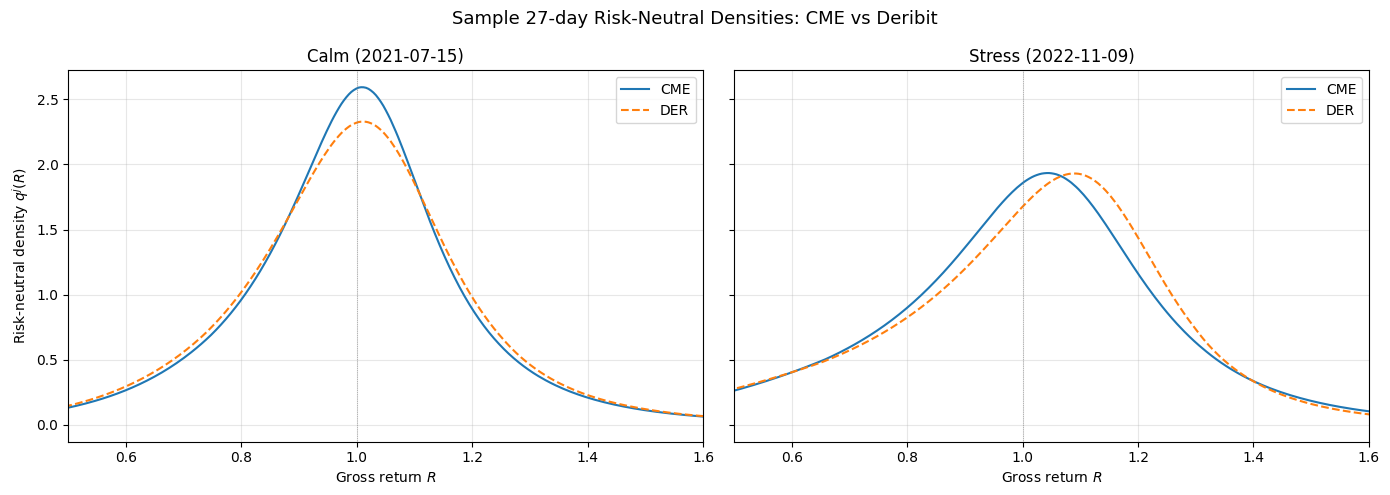

  Saved: c:\Projects\bitcoin-risk-premia\results\svi\figures\fig_rnd_sample.png


In [9]:
TAU_DAYS = 27
calm_date = "2021-07-15"
stress_date = "2022-11-09"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (date_str, label) in zip(axes, [(calm_date, f"Calm ({calm_date})"), 
                                       (stress_date, f"Stress ({stress_date})")]):
    for venue, color, ls in [("CME", "C0", "-"), ("DER", "C1", "--")]:
        
        density_path = SURFACES_DIR / f"rnd_{venue}_densities.parquet"
        df_rnd = pd.read_parquet(density_path)
        df_rnd["date"] = pd.to_datetime(df_rnd["date"])
        
        row = df_rnd[(df_rnd["date"] == pd.to_datetime(date_str)) & 
                     (df_rnd["tau_days"] == TAU_DAYS)]
        
        if len(row) > 0:
            row = row.iloc[0]
            R = np.array(row["returns"])
            q = np.array(row["density"])
            
            R_GRID = np.linspace(R.min(), R.max(), 1000)
            q_interp = np.interp(R_GRID, R, q, left=0, right=0)
            
            mass = np.trapezoid(q_interp, R_GRID)
            if mass > 0:
                q_interp /= mass
                
            ax.plot(R_GRID, q_interp, color=color, ls=ls, lw=1.5, label=venue)
        else:
            print(f"    [WARN] No RND for {venue} on {date_str}")
            
    ax.axvline(1.0, color="gray", lw=0.5, ls=":")
    ax.set_xlabel("Gross return $R$")
    ax.set_xlim(0.50, 1.60)
    ax.set_title(label)
    ax.legend(fontsize=10)

axes[0].set_ylabel("Risk-neutral density $q^j(R)$")
fig.suptitle("Sample 27-day Risk-Neutral Densities: CME vs Deribit", fontsize=13)
plt.tight_layout()

plt.savefig(FIG_DIR / "fig_rnd_sample.png", dpi=150)
plt.show()
print(f"  Saved: {FIG_DIR / 'fig_rnd_sample.png'}")